# House Price Prediction — EDA, Feature Engineering & Modeling

**Dataset:** Ames Housing (Kaggle — House Prices: Advanced Regression Techniques)
**Goal:** Predict `SalePrice` from 79 explanatory variables covering size, quality, location, and condition of residential homes in Ames, Iowa.

This notebook covers:
1. Exploratory Data Analysis (EDA)
2. Data cleaning & feature engineering
3. Model training & comparison (Linear, Ridge, Random Forest, Gradient Boosting)
4. Feature importance & key takeaways


In [11]:
import os
print(os.getcwd())

/workspaces/Housing-Price-Prediction/Notebook


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('/workspaces/Housing-Price-Prediction/Data/train.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Exploratory Data Analysis

### 1.1 Target Variable — SalePrice
The target is right-skewed, which is typical for price data. A log transform makes it closer to normal — useful since several models (esp. linear ones) perform better on roughly normal targets.

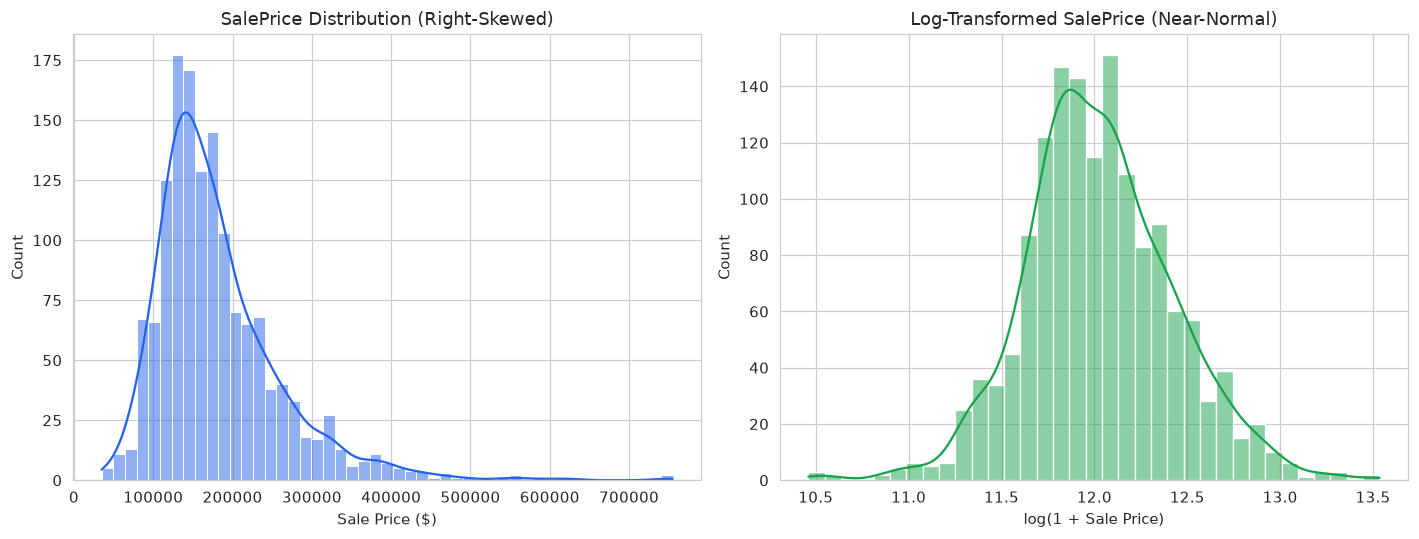

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title('SalePrice Distribution (Right-Skewed)')
axes[0].set_xlabel('Sale Price ($)')

sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='#16a34a')
axes[1].set_title('Log-Transformed SalePrice (Near-Normal)')
axes[1].set_xlabel('log(1 + Sale Price)')
plt.tight_layout()
plt.show()

print(df['SalePrice'].describe())

### 1.2 Missing Data
Several columns have high missingness — but in this dataset, `NA` often has meaning (e.g. `NA` in `PoolQC` means "no pool", not a data quality issue). This shapes how we handle it in feature engineering.

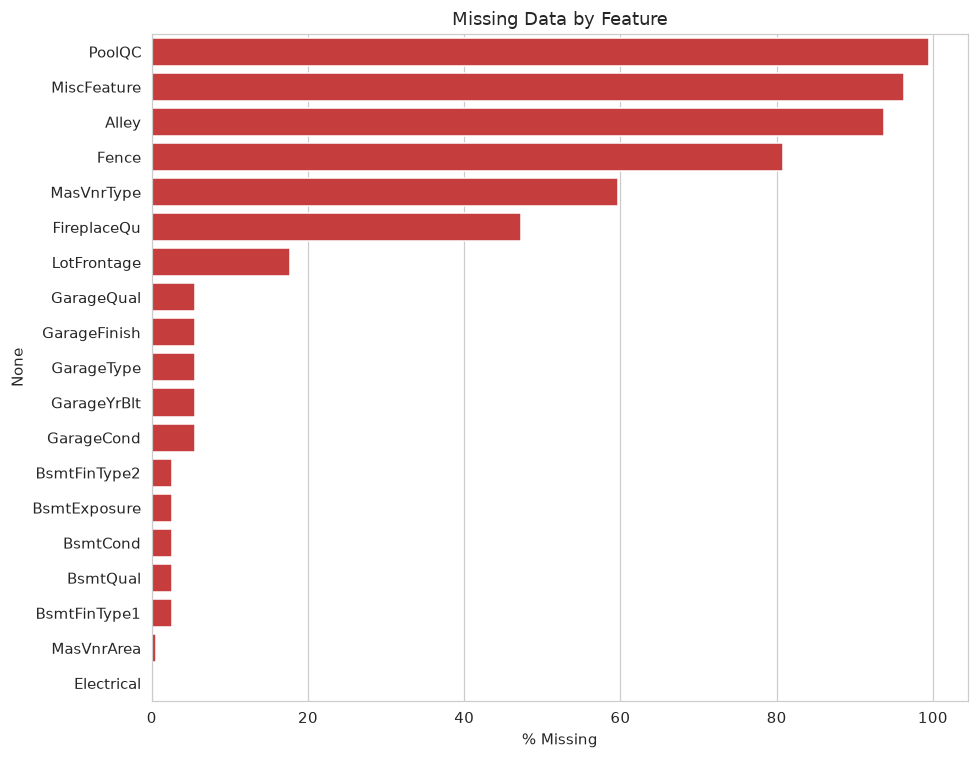

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
dtype: float64

In [14]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(9, 7))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color='#dc2626')
plt.xlabel('% Missing')
plt.title('Missing Data by Feature')
plt.tight_layout()
plt.show()

missing_pct.head(10)

### 1.3 Correlation with SalePrice
Looking at which numeric features move most closely with price.

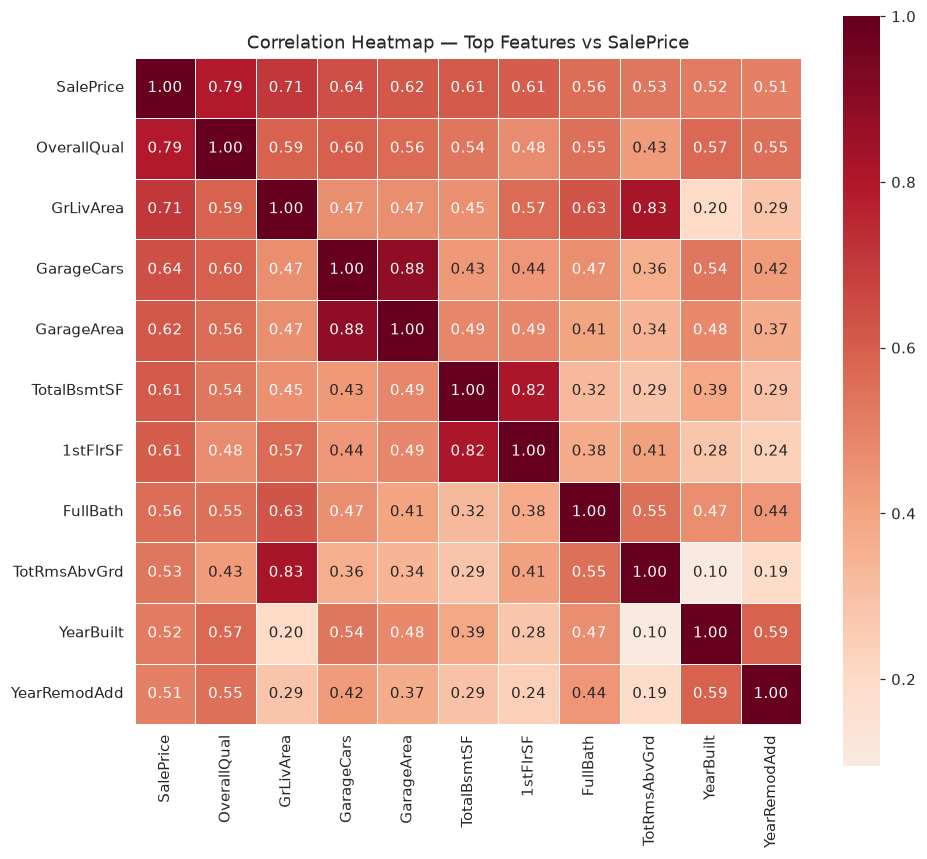

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

In [15]:
numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
top_corr_features = corr_with_target.head(11).index.tolist()

plt.figure(figsize=(9, 8))
sns.heatmap(numeric_df[top_corr_features].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Top Features vs SalePrice')
plt.tight_layout()
plt.show()

corr_with_target.head(11)[1:]

### 1.4 Key Relationships
A closer look at the strongest individual drivers: living area, overall quality, year built, and neighborhood.

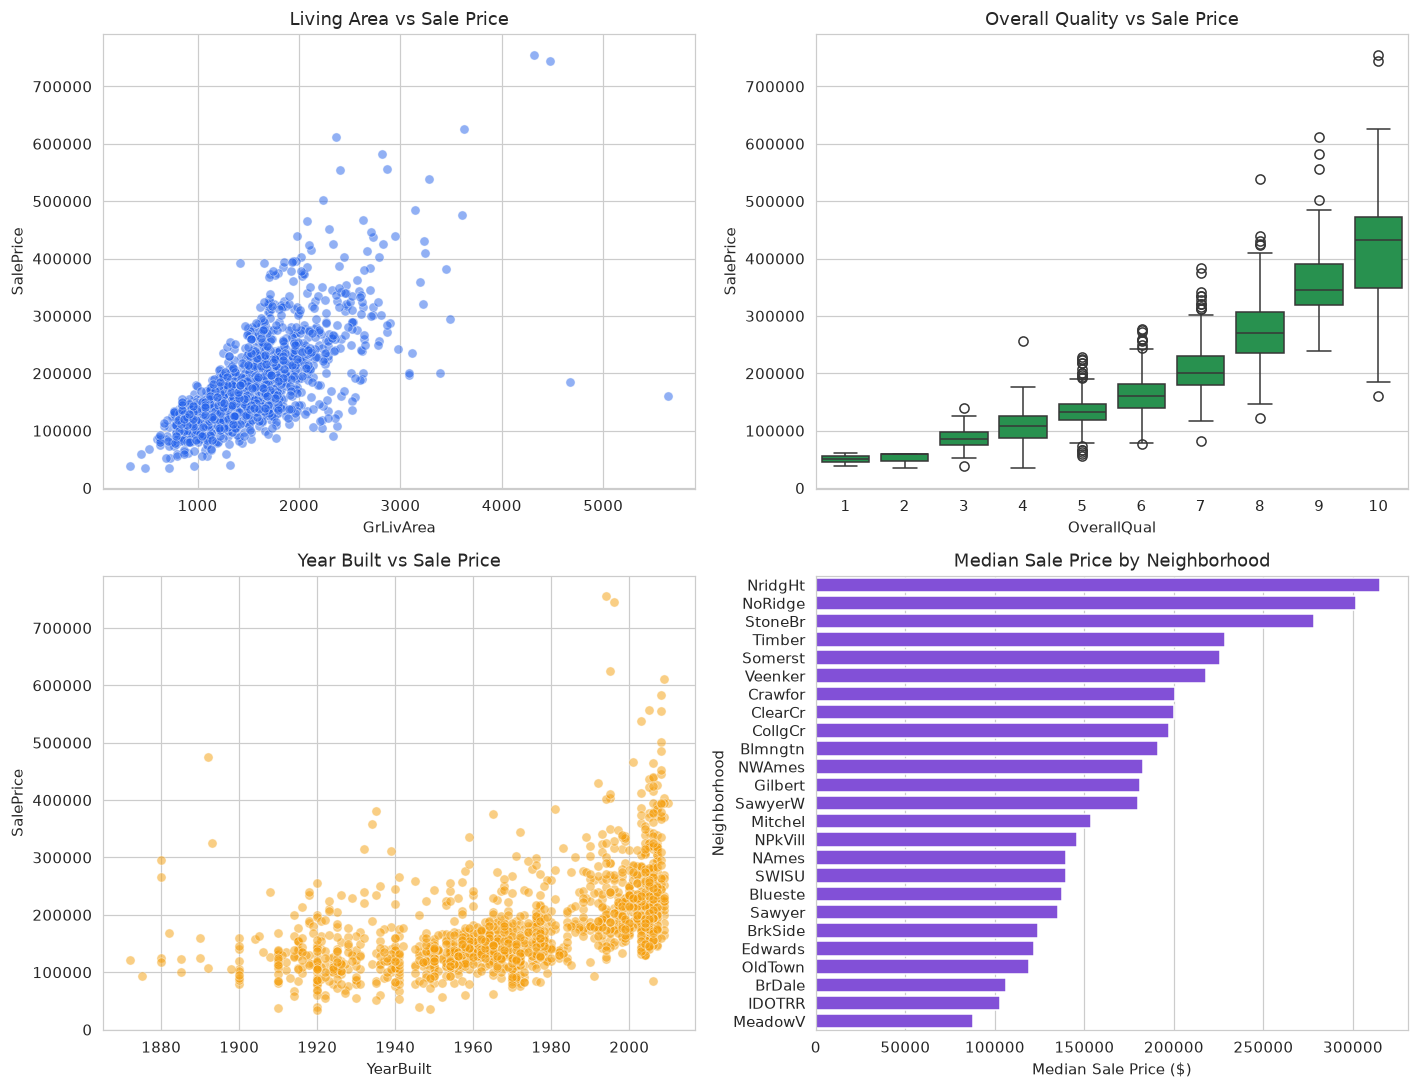

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.5, ax=axes[0,0], color='#2563eb')
axes[0,0].set_title('Living Area vs Sale Price')

sns.boxplot(data=df, x='OverallQual', y='SalePrice', ax=axes[0,1], color='#16a34a')
axes[0,1].set_title('Overall Quality vs Sale Price')

sns.scatterplot(data=df, x='YearBuilt', y='SalePrice', alpha=0.5, ax=axes[1,0], color='#f59e0b')
axes[1,0].set_title('Year Built vs Sale Price')

neighborhood_avg = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
sns.barplot(x=neighborhood_avg.values, y=neighborhood_avg.index, ax=axes[1,1], color='#7c3aed')
axes[1,1].set_title('Median Sale Price by Neighborhood')
axes[1,1].set_xlabel('Median Sale Price ($)')

plt.tight_layout()
plt.show()

**Observations:**
- `GrLivArea` (above-ground living area) has a strong, roughly linear relationship with price — with a couple of large-area/low-price outliers worth noting.
- `OverallQual` is one of the single strongest predictors — a near-monotonic step up in price per quality point.
- Newer homes trend toward higher prices, but with wide variance — age alone isn't the whole story.
- Neighborhood median prices vary by more than 4x between the most and least expensive areas — location matters as much as any physical attribute.

## 2. Feature Engineering

Steps taken:
- Dropped columns that are >80% missing (`PoolQC`, `MiscFeature`, `Alley`, `Fence`) — too sparse to model reliably.
- Filled categorical missing values with `'None'` — since in this dataset, missing usually means "feature not present" rather than "unknown".
- Filled numeric missing values with the column median.
- Created derived features: `HouseAge`, `RemodAge`, `TotalSF` (combined floor area), `TotalBathrooms` (weighted total).
- Label-encoded categorical variables for use in tree-based models.
- Log-transformed `SalePrice` to reduce skew for training.

In [17]:
data = df.copy()

high_missing_cols = missing_pct[missing_pct > 80].index.tolist()
data = data.drop(columns=high_missing_cols)

cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    data[col] = data[col].fillna('None')

num_cols = data.select_dtypes(include=[np.number]).columns
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

data['HouseAge'] = data['YrSold'] - data['YearBuilt']
data['RemodAge'] = data['YrSold'] - data['YearRemodAdd']
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']
data['TotalBathrooms'] = (data['FullBath'] + 0.5 * data['HalfBath'] +
                           data['BsmtFullBath'] + 0.5 * data['BsmtHalfBath'])

data['SalePrice_log'] = np.log1p(data['SalePrice'])

le_cols = data.select_dtypes(include='object').columns
for col in le_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

print(f"Final feature set shape: {data.shape}")

Final feature set shape: (1460, 82)


## 3. Modeling

Trained four models to compare a linear baseline against tree-based ensembles, using 5-fold cross-validation and an 80/20 train-test split.

In [18]:
drop_cols = ['Id', 'SalePrice', 'SalePrice_log']
X = data.drop(columns=drop_cols)
y = data['SalePrice_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    preds_actual = np.expm1(preds)
    y_test_actual = np.expm1(y_test)

    rmse_log = np.sqrt(mean_squared_error(y_test, preds))
    rmse_dollar = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
    mae_dollar = mean_absolute_error(y_test_actual, preds_actual)
    r2 = r2_score(y_test, preds)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    results.append({
        'Model': name,
        'R2 Score': round(r2, 4),
        'CV R2 (mean)': round(cv_scores.mean(), 4),
        'RMSE (log)': round(rmse_log, 4),
        'RMSE ($)': round(rmse_dollar, 0),
        'MAE ($)': round(mae_dollar, 0)
    })

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False)
results_df

,Model,R2 Score,CV R2 (mean),RMSE (log),RMSE ($),MAE ($)
3,Gradient Boosting,0.8977,0.8890,0.1382,28826.0,16158.0
2,Random Forest,0.8873,0.8688,0.1450,29341.0,17079.0
1,Ridge Regression,0.8715,0.8410,0.1549,27879.0,18163.0
0,Linear Regression,0.8714,0.8400,0.1549,27889.0,18266.0


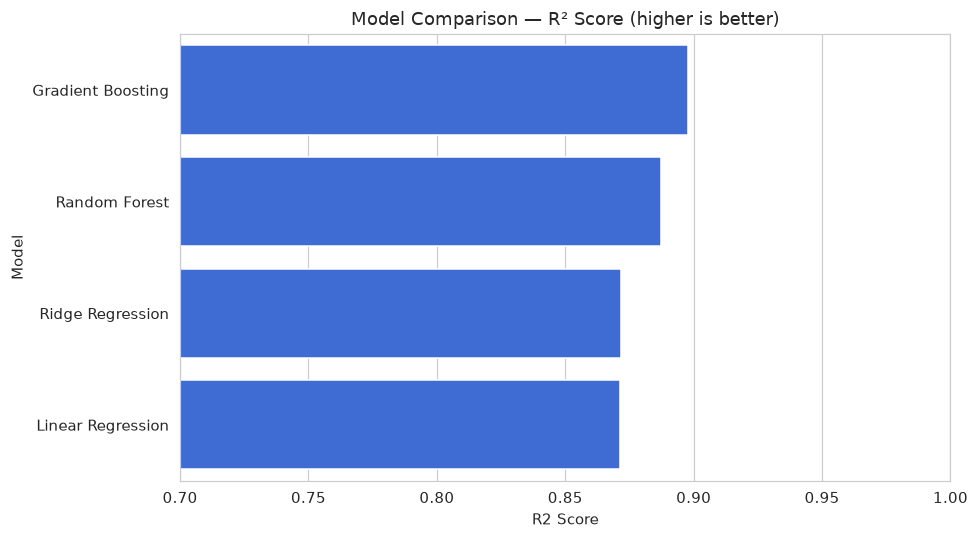

In [19]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x='R2 Score', y='Model', color='#2563eb')
plt.title('Model Comparison — R\u00b2 Score (higher is better)')
plt.xlim(0.7, 1.0)
plt.tight_layout()
plt.show()

**Result:** Gradient Boosting performed best (R² ≈ 0.90 on held-out test data), followed closely by Random Forest. Both tree-based ensembles outperformed the linear baselines, suggesting non-linear interactions between features (e.g. quality × size × neighborhood) that linear models can't capture as well.

On average, the best model's predictions are within roughly $16-17K of actual sale price (MAE) — on a dataset where median price is ~$163K, that's a reasonably tight margin for a first-pass model.

## 4. Feature Importance

Which features does the best model actually rely on?

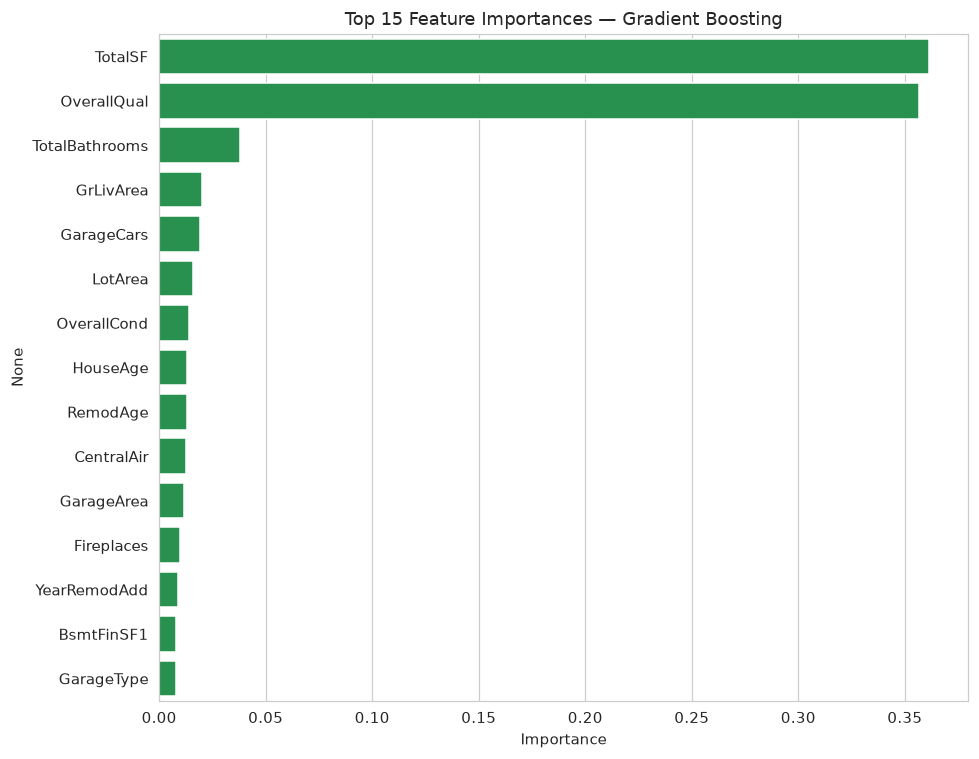

TotalSF           0.361556
OverallQual       0.356570
TotalBathrooms    0.038018
GrLivArea         0.020014
GarageCars        0.019254
LotArea           0.015756
OverallCond       0.014112
HouseAge          0.012977
RemodAge          0.012881
CentralAir        0.012790
dtype: float64

In [20]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index, color='#16a34a')
plt.title(f'Top 15 Feature Importances \u2014 {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(10)

## 5. Key Takeaways

- **Size and quality dominate.** The engineered `TotalSF` feature (combined basement + 1st + 2nd floor area) and `OverallQual` together account for the majority of the model's predictive power — together explaining more than any single raw column in the original dataset.
- **Feature engineering paid off.** Combining basement, 1st floor, and 2nd floor area into a single `TotalSF` feature outperformed using the individual columns separately — a reminder that raw columns aren't always the most useful signal on their own.
- **Tree-based models handled non-linearity better than linear regression**, likely because price depends on *interactions* between features (e.g. a large house is worth much more if it's also high quality) rather than just their individual effects.
- **Next steps to improve further:** hyperparameter tuning (grid/random search), trying XGBoost/LightGBM, handling outliers in `GrLivArea` more explicitly, and exploring target encoding for high-cardinality categoricals like `Neighborhood`.
